# Base vs LoRA Fine-Tuned Model Evaluation

This notebook evaluates the base Llama 3.1 8B model against the LoRA fine-tuned version using:
- 1000 random samples from the Alpaca dataset
- Claude Sonnet as an impartial judge (binary YES/NO scoring) via Vertex AI
- Throughput measurement (tokens/sec) for both models

**Prerequisites:**
- Both vLLM servers running via `./scripts/serve_k8s.sh`
- GCP authentication configured (`gcloud auth login`)
- `.venv` with `anthropic[vertex] openai datasets matplotlib seaborn pandas` installed

**Parameters (prompted on run):**
- `BASE_IP` — LoadBalancer IP of the base model vLLM server
- `LORA_IP` — LoadBalancer IP of the LoRA model vLLM server
- `GCP_PROJECT_ID` — GCP project ID for Vertex AI (or set `ANTHROPIC_VERTEX_PROJECT_ID`)
- `GCP_REGION` — GCP region for Vertex AI (default: `europe-west1`)

**Checkpointing:** Each step saves results to `results/`. If execution fails mid-way, re-running a step will resume from the checkpoint automatically.

In [2]:
!pip install -q 'anthropic[vertex]' openai datasets matplotlib seaborn pandas


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## 1. Configuration

In [2]:
import os
import json

# Prompt for required parameters
BASE_IP = os.environ.get("BASE_IP") or input("Base model LoadBalancer IP: ").strip()
LORA_IP = os.environ.get("LORA_IP") or input("LoRA model LoadBalancer IP: ").strip()
GCP_PROJECT_ID = os.environ.get("ANTHROPIC_VERTEX_PROJECT_ID") or input("GCP Project ID for Vertex AI: ").strip()
GCP_REGION = os.environ.get("ANTHROPIC_VERTEX_REGION", "us-east5")

BASE_URL = f"http://{BASE_IP}:8000"
LORA_URL = f"http://{LORA_IP}:8000"

BASE_MODEL_NAME = "/mnt/data/Llama-3.1-8B"
LORA_MODEL_NAME = "lora-adapter"

NUM_SAMPLES = 1000
MAX_TOKENS = 512
TEMPERATURE = 0.1
SEED = 42
PARALLEL_WORKERS = 4
JUDGE_DELAY = 1.0

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

config = {
    "base_url": BASE_URL, "lora_url": LORA_URL,
    "num_samples": NUM_SAMPLES, "max_tokens": MAX_TOKENS,
    "temperature": TEMPERATURE, "seed": SEED,
    "judge_model": "claude-sonnet-4-6", "judge_provider": "vertex-ai",
}
with open(f"{RESULTS_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"Base URL:    {BASE_URL}")
print(f"LoRA URL:    {LORA_URL}")
print(f"GCP Project: {GCP_PROJECT_ID}")
print(f"GCP Region:  {GCP_REGION}")
print(f"Samples:     {NUM_SAMPLES}")
print(f"Workers:     {PARALLEL_WORKERS}")
print(f"Judge delay: {JUDGE_DELAY}s")

Base URL:    http://89.169.113.193:8000
LoRA URL:    http://89.169.122.10:8000
GCP Project: itpc-gcp-global-revenue-claude
GCP Region:  us-east5
Samples:     1000
Workers:     4
Judge delay: 1.0s


## 2. Load and Sample Dataset

In [4]:
from datasets import load_dataset

SAMPLES_FILE = f"{RESULTS_DIR}/samples.json"

if os.path.exists(SAMPLES_FILE):
    with open(SAMPLES_FILE) as f:
        samples = json.load(f)
    print(f"Loaded {len(samples)} samples from checkpoint: {SAMPLES_FILE}")
else:
    dataset = load_dataset("tatsu-lab/alpaca", split="train")
    dataset = dataset.shuffle(seed=SEED).select(range(NUM_SAMPLES))
    samples = [dict(s) for s in dataset]
    with open(SAMPLES_FILE, "w") as f:
        json.dump(samples, f)
    print(f"Loaded {len(samples)} samples from Alpaca dataset (saved to {SAMPLES_FILE})")

print(f"\nExample:")
print(f"  Instruction: {samples[0]['instruction'][:100]}...")
print(f"  Input:       {samples[0].get('input', '')[:100]}")
print(f"  Output:      {samples[0]['output'][:100]}...")

Loaded 1000 samples from Alpaca dataset (saved to results/samples.json)

Example:
  Instruction: What would be the best type of exercise for a person who has arthritis?...
  Input:       
  Output:      For someone with arthritis, the best type of exercise would be low-impact activities like yoga, swim...


## 3. Query Both Models

In [5]:
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from openai import OpenAI

base_client = OpenAI(api_key="EMPTY", base_url=f"{BASE_URL}/v1")
lora_client = OpenAI(api_key="EMPTY", base_url=f"{LORA_URL}/v1")


def format_prompt(instruction, input_text=""):
    if input_text:
        return f"### Instruction:\n{instruction}\n\n### Input:\n{input_text}\n\n### Response:\n"
    return f"### Instruction:\n{instruction}\n\n### Response:\n"


def query_model(client, model_name, instruction, input_text=""):
    prompt = format_prompt(instruction, input_text)
    start = time.time()
    response = client.completions.create(
        model=model_name,
        prompt=prompt,
        max_tokens=MAX_TOKENS,
        temperature=TEMPERATURE,
    )
    elapsed = time.time() - start
    text = response.choices[0].text.strip()
    tokens = response.usage.completion_tokens
    return text, elapsed, tokens


def query_sample(i, sample):
    instruction = sample["instruction"]
    input_text = sample.get("input", "") or ""
    result = {
        "index": i,
        "instruction": instruction,
        "input": input_text,
        "expected": sample.get("output", ""),
    }
    try:
        text, elapsed, tokens = query_model(base_client, BASE_MODEL_NAME, instruction, input_text)
        result["base_response"] = text
        result["base_time"] = elapsed
        result["base_tokens"] = tokens
    except Exception as e:
        result["base_response"] = ""
        result["base_time"] = 0
        result["base_tokens"] = 0
        result["base_error"] = str(e)

    try:
        text, elapsed, tokens = query_model(lora_client, LORA_MODEL_NAME, instruction, input_text)
        result["lora_response"] = text
        result["lora_time"] = elapsed
        result["lora_tokens"] = tokens
    except Exception as e:
        result["lora_response"] = ""
        result["lora_time"] = 0
        result["lora_tokens"] = 0
        result["lora_error"] = str(e)

    return result

In [6]:
QUERY_CHECKPOINT = f"{RESULTS_DIR}/query_results.json"
SAMPLES_FILE = f"{RESULTS_DIR}/samples.json"

# Load samples from checkpoint if not in memory
if "samples" not in dir() or not samples:
    assert os.path.exists(SAMPLES_FILE), f"Run step 2 first — {SAMPLES_FILE} not found"
    with open(SAMPLES_FILE) as f:
        samples = json.load(f)
    print(f"Loaded {len(samples)} samples from {SAMPLES_FILE}")

if os.path.exists(QUERY_CHECKPOINT):
    with open(QUERY_CHECKPOINT) as f:
        results = json.load(f)
    completed_indices = {r["index"] for r in results}
    remaining = [(i, s) for i, s in enumerate(samples) if i not in completed_indices]
    print(f"Resuming from checkpoint: {len(results)} done, {len(remaining)} remaining")
else:
    results = []
    remaining = list(enumerate(samples))
    print(f"Starting fresh: {len(remaining)} samples to query")

if remaining:
    print(f"\nQuerying both models ({PARALLEL_WORKERS} workers)...\n")
    start_time = time.time()
    total_target = len(remaining) + len(results)

    with ThreadPoolExecutor(max_workers=PARALLEL_WORKERS) as executor:
        futures = {executor.submit(query_sample, i, s): i for i, s in remaining}
        for future in as_completed(futures):
            result = future.result()
            results.append(result)
            done = len(results)
            if done % 50 == 0 or done == total_target:
                elapsed = time.time() - start_time
                results.sort(key=lambda x: x["index"])
                with open(QUERY_CHECKPOINT, "w") as f:
                    json.dump(results, f)
                print(f"  [{done:4d}/{total_target}] {elapsed:.0f}s — checkpointed")

    results.sort(key=lambda x: x["index"])
    with open(QUERY_CHECKPOINT, "w") as f:
        json.dump(results, f)
    print(f"\nDone. Total query time: {time.time() - start_time:.1f}s")
else:
    print("All samples already queried.")

print(f"Saved: {QUERY_CHECKPOINT} ({len(results)} results)")

Resuming from checkpoint: 1000 done, 0 remaining
All samples already queried.
Saved: results/query_results.json (1000 results)


## 4. Claude Sonnet Judge (Vertex AI)

Uses Claude Sonnet via GCP Vertex AI as an impartial judge. Rate-limited with delays and retries. Results are checkpointed per-sample so interrupted runs can resume.

In [7]:
import anthropic
import threading

judge_client = anthropic.AnthropicVertex(
    project_id=GCP_PROJECT_ID,
    region=GCP_REGION,
)
JUDGE_MODEL = "claude-sonnet-4-6"

_rate_lock = threading.Lock()

JUDGE_SYSTEM = """You are an impartial judge evaluating AI model responses.
Given an instruction (and optional input) and the model's response, decide whether
the response is correct, relevant, and helpful.

Rules:
- Answer ONLY "YES" or "NO".
- YES means the response correctly addresses the instruction, is factually reasonable,
  and provides a useful answer.
- NO means the response is wrong, irrelevant, incomplete, or nonsensical."""

JUDGE_TEMPLATE = """### Instruction:
{instruction}

{input_section}### Model Response:
{response}

Is this response correct, relevant, and helpful? Answer YES or NO."""


def judge_response(instruction, input_text, response):
    if not response:
        return 0
    input_section = f"### Input:\n{input_text}\n\n" if input_text else ""
    user_msg = JUDGE_TEMPLATE.format(
        instruction=instruction,
        input_section=input_section,
        response=response,
    )
    max_retries = 5
    for attempt in range(max_retries):
        try:
            with _rate_lock:
                time.sleep(JUDGE_DELAY)
            result = judge_client.messages.create(
                model=JUDGE_MODEL,
                max_tokens=5,
                temperature=0,
                system=JUDGE_SYSTEM,
                messages=[{"role": "user", "content": user_msg}],
            )
            answer = result.content[0].text.strip().upper()
            return 1 if answer.startswith("YES") else 0
        except anthropic.RateLimitError:
            wait = 2 ** attempt * 5
            print(f"    Rate limited, waiting {wait}s (attempt {attempt+1}/{max_retries})")
            time.sleep(wait)
        except Exception as e:
            if "rate" in str(e).lower() or "429" in str(e):
                wait = 2 ** attempt * 5
                print(f"    Rate limited, waiting {wait}s (attempt {attempt+1}/{max_retries})")
                time.sleep(wait)
            else:
                print(f"    Judge error: {e}")
                return 0
    print(f"    Max retries exceeded")
    return 0


def judge_sample(result):
    result["base_score"] = judge_response(
        result["instruction"], result["input"], result.get("base_response", "")
    )
    result["lora_score"] = judge_response(
        result["instruction"], result["input"], result.get("lora_response", "")
    )
    return result

print(f"Judge ready: {JUDGE_MODEL} via Vertex AI ({GCP_PROJECT_ID} / {GCP_REGION})")

Judge ready: claude-sonnet-4-6 via Vertex AI (itpc-gcp-global-revenue-claude / us-east5)


In [8]:
import time
import json
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

QUERY_CHECKPOINT = f"{RESULTS_DIR}/query_results.json"
JUDGE_CHECKPOINT = f"{RESULTS_DIR}/judge_results.json"

# Load query results from checkpoint (so step 3 can be skipped)
assert os.path.exists(QUERY_CHECKPOINT), f"Run step 3 first — {QUERY_CHECKPOINT} not found"
with open(QUERY_CHECKPOINT) as f:
    results = json.load(f)
print(f"Loaded {len(results)} query results from {QUERY_CHECKPOINT}")

if os.path.exists(JUDGE_CHECKPOINT):
    with open(JUDGE_CHECKPOINT) as f:
        judged_results = json.load(f)
    judged_indices = {r["index"] for r in judged_results if "base_score" in r}
    remaining_judge = [r for r in results if r["index"] not in judged_indices]
    print(f"Resuming from checkpoint: {len(judged_results)} judged, {len(remaining_judge)} remaining")
else:
    judged_results = []
    remaining_judge = list(results)
    print(f"Starting fresh: {len(remaining_judge)} samples to judge")

if remaining_judge:
    print(f"\nJudging with Claude Sonnet ({PARALLEL_WORKERS} workers, {JUDGE_DELAY}s delay)...\n")
    start_time = time.time()
    total_target = len(remaining_judge) + len(judged_results)
    newly_judged = 0

    with ThreadPoolExecutor(max_workers=PARALLEL_WORKERS) as executor:
        futures = {executor.submit(judge_sample, dict(r)): r["index"] for r in remaining_judge}
        for future in as_completed(futures):
            result = future.result()
            judged_results.append(result)
            newly_judged += 1
            done = len(judged_results)
            if newly_judged % 25 == 0 or done == total_target:
                elapsed = time.time() - start_time
                base_acc = sum(r.get("base_score", 0) for r in judged_results) / done * 100
                lora_acc = sum(r.get("lora_score", 0) for r in judged_results) / done * 100
                judged_results.sort(key=lambda x: x["index"])
                with open(JUDGE_CHECKPOINT, "w") as f:
                    json.dump(judged_results, f)
                print(f"  [{done:4d}/{total_target}] Base: {base_acc:.1f}% | LoRA: {lora_acc:.1f}% | {elapsed:.0f}s — checkpointed")

    judged_results.sort(key=lambda x: x["index"])
    with open(JUDGE_CHECKPOINT, "w") as f:
        json.dump(judged_results, f)
    print(f"\nJudging complete. Time: {time.time() - start_time:.1f}s")
else:
    print("All samples already judged.")

print(f"Saved: {JUDGE_CHECKPOINT} ({len(judged_results)} results)")

Loaded 1000 query results from results/query_results.json
Starting fresh: 1000 samples to judge

Judging with Claude Sonnet (4 workers, 1.0s delay)...

  [  25/1000] Base: 56.0% | LoRA: 84.0% | 54s — checkpointed
  [  50/1000] Base: 52.0% | LoRA: 86.0% | 103s — checkpointed
  [  75/1000] Base: 53.3% | LoRA: 86.7% | 154s — checkpointed
  [ 100/1000] Base: 54.0% | LoRA: 85.0% | 205s — checkpointed
  [ 125/1000] Base: 52.8% | LoRA: 84.8% | 254s — checkpointed
  [ 150/1000] Base: 52.0% | LoRA: 85.3% | 304s — checkpointed
  [ 175/1000] Base: 54.3% | LoRA: 85.1% | 352s — checkpointed
  [ 200/1000] Base: 54.5% | LoRA: 85.5% | 402s — checkpointed
  [ 225/1000] Base: 53.8% | LoRA: 85.8% | 455s — checkpointed
  [ 250/1000] Base: 52.4% | LoRA: 86.0% | 505s — checkpointed
  [ 275/1000] Base: 52.7% | LoRA: 86.5% | 555s — checkpointed
  [ 300/1000] Base: 51.7% | LoRA: 87.3% | 604s — checkpointed
  [ 325/1000] Base: 52.0% | LoRA: 87.4% | 654s — checkpointed
  [ 350/1000] Base: 51.4% | LoRA: 86.6% | 7

## 5. Save Results

In [9]:
import pandas as pd

df = pd.DataFrame(judged_results)

df.to_csv(f"{RESULTS_DIR}/eval_details.csv", index=False)
df.to_json(f"{RESULTS_DIR}/eval_details.json", orient="records", indent=2)

summary = {
    "num_samples": len(df),
    "judge_model": JUDGE_MODEL,
    "judge_provider": "vertex-ai",
    "base_accuracy": round(df["base_score"].mean() * 100, 2),
    "lora_accuracy": round(df["lora_score"].mean() * 100, 2),
    "improvement": round((df["lora_score"].mean() - df["base_score"].mean()) * 100, 2),
    "base_avg_tokens": round(df["base_tokens"].mean(), 1),
    "lora_avg_tokens": round(df["lora_tokens"].mean(), 1),
    "base_avg_latency_s": round(df["base_time"].mean(), 3),
    "lora_avg_latency_s": round(df["lora_time"].mean(), 3),
    "base_throughput_tok_s": round(df["base_tokens"].sum() / df["base_time"].sum(), 1),
    "lora_throughput_tok_s": round(df["lora_tokens"].sum() / df["lora_time"].sum(), 1),
}

with open(f"{RESULTS_DIR}/eval_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved to results/:")
print(f"  eval_details.csv   ({len(df)} rows)")
print(f"  eval_details.json  ({len(df)} records)")
print(f"  eval_summary.json")
print(f"\nSummary:")
for k, v in summary.items():
    print(f"  {k}: {v}")

Saved to results/:
  eval_details.csv   (1000 rows)
  eval_details.json  (1000 records)
  eval_summary.json

Summary:
  num_samples: 1000
  judge_model: claude-sonnet-4-6
  judge_provider: vertex-ai
  base_accuracy: 52.2
  lora_accuracy: 85.1
  improvement: 32.9
  base_avg_tokens: 241.7
  lora_avg_tokens: 57.7
  base_avg_latency_s: 5.58
  lora_avg_latency_s: 1.533
  base_throughput_tok_s: 43.3
  lora_throughput_tok_s: 37.6


## 6. Accuracy Analysis

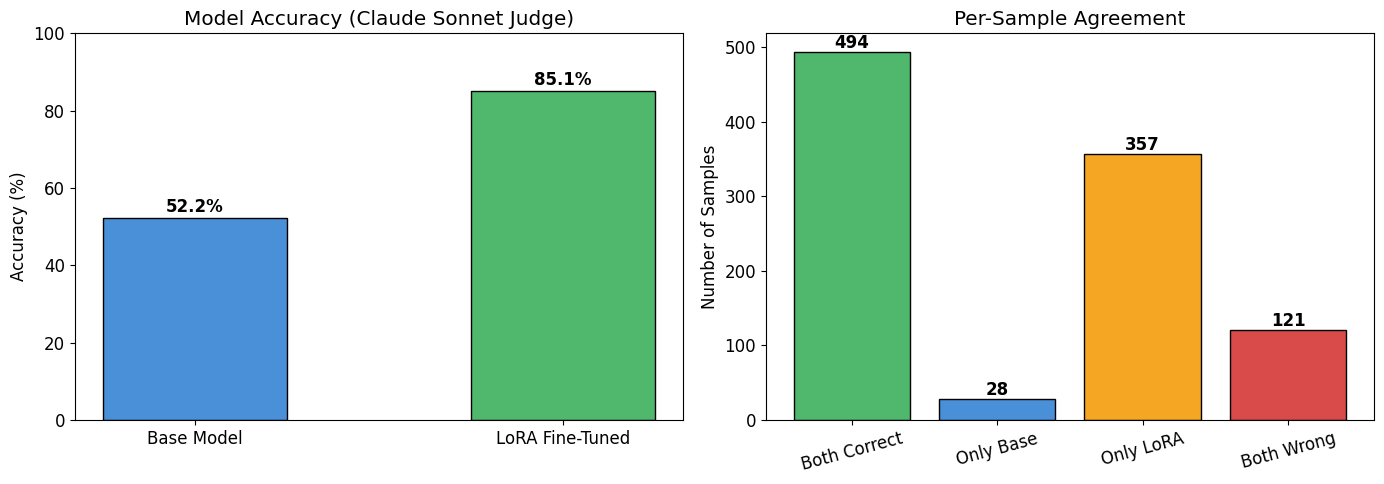

Saved: results/accuracy_comparison.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 12})

base_acc = df["base_score"].mean() * 100
lora_acc = df["lora_score"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: accuracy comparison
bars = axes[0].bar(["Base Model", "LoRA Fine-Tuned"], [base_acc, lora_acc],
                   color=["#4a90d9", "#50b86c"], width=0.5, edgecolor="black")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Model Accuracy (Claude Sonnet Judge)")
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, [base_acc, lora_acc]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                 f"{val:.1f}%", ha="center", fontweight="bold")

# Stacked bar: per-sample agreement
both_correct = ((df["base_score"] == 1) & (df["lora_score"] == 1)).sum()
only_base = ((df["base_score"] == 1) & (df["lora_score"] == 0)).sum()
only_lora = ((df["base_score"] == 0) & (df["lora_score"] == 1)).sum()
both_wrong = ((df["base_score"] == 0) & (df["lora_score"] == 0)).sum()

categories = ["Both Correct", "Only Base", "Only LoRA", "Both Wrong"]
values = [both_correct, only_base, only_lora, both_wrong]
colors = ["#50b86c", "#4a90d9", "#f5a623", "#d94a4a"]

bars2 = axes[1].bar(categories, values, color=colors, edgecolor="black")
axes[1].set_ylabel("Number of Samples")
axes[1].set_title("Per-Sample Agreement")
axes[1].tick_params(axis="x", rotation=15)
for bar, val in zip(bars2, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(val), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR}/accuracy_comparison.png")

## 7. Confusion Matrix

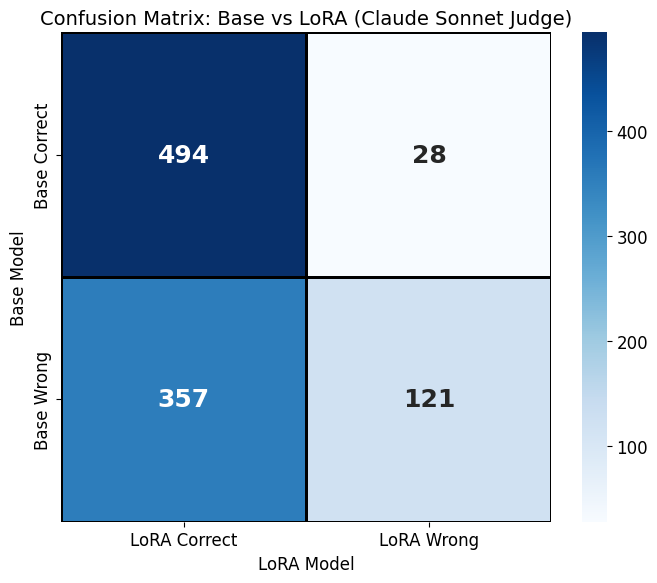

Saved: results/confusion_matrix.png

Interpretation:
  Both correct:        494 (49.4%)
  Only base correct:    28 (2.8%) — LoRA regression
  Only LoRA correct:   357 (35.7%) — LoRA improvement
  Both wrong:          121 (12.1%)


In [11]:
import seaborn as sns
import numpy as np

confusion = np.array([
    [both_correct, only_base],
    [only_lora, both_wrong],
])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["LoRA Correct", "LoRA Wrong"],
    yticklabels=["Base Correct", "Base Wrong"],
    linewidths=1,
    linecolor="black",
    annot_kws={"size": 18, "fontweight": "bold"},
    ax=ax,
)
ax.set_title("Confusion Matrix: Base vs LoRA (Claude Sonnet Judge)", fontsize=14)
ax.set_xlabel("LoRA Model", fontsize=12)
ax.set_ylabel("Base Model", fontsize=12)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {RESULTS_DIR}/confusion_matrix.png")
print(f"\nInterpretation:")
print(f"  Both correct:       {both_correct:4d} ({both_correct/len(df)*100:.1f}%)")
print(f"  Only base correct:  {only_base:4d} ({only_base/len(df)*100:.1f}%) — LoRA regression")
print(f"  Only LoRA correct:  {only_lora:4d} ({only_lora/len(df)*100:.1f}%) — LoRA improvement")
print(f"  Both wrong:         {both_wrong:4d} ({both_wrong/len(df)*100:.1f}%)")

## 8. Throughput Analysis

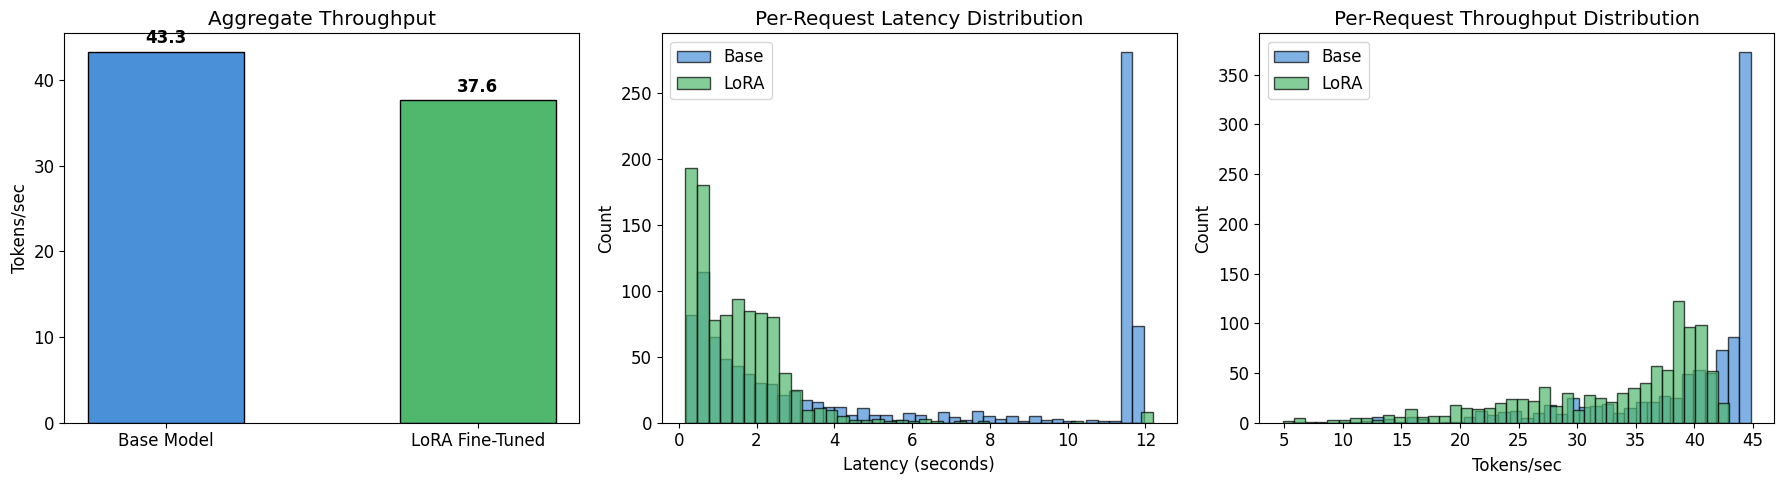

Saved: results/throughput_analysis.png

Throughput Summary:
  Base:  43.3 tok/s (avg latency: 5.580s, p95: 11.673s)
  LoRA:  37.6 tok/s (avg latency: 1.533s, p95: 3.479s)
  Overhead: -13.1% throughput change with LoRA


In [12]:
base_tok_s = df["base_tokens"].sum() / df["base_time"].sum()
lora_tok_s = df["lora_tokens"].sum() / df["lora_time"].sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Throughput bar chart
bars = axes[0].bar(["Base Model", "LoRA Fine-Tuned"], [base_tok_s, lora_tok_s],
                   color=["#4a90d9", "#50b86c"], width=0.5, edgecolor="black")
axes[0].set_ylabel("Tokens/sec")
axes[0].set_title("Aggregate Throughput")
for bar, val in zip(bars, [base_tok_s, lora_tok_s]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.1f}", ha="center", fontweight="bold")

# Latency distribution
axes[1].hist(df["base_time"], bins=40, alpha=0.7, label="Base", color="#4a90d9", edgecolor="black")
axes[1].hist(df["lora_time"], bins=40, alpha=0.7, label="LoRA", color="#50b86c", edgecolor="black")
axes[1].set_xlabel("Latency (seconds)")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-Request Latency Distribution")
axes[1].legend()

# Per-request throughput (tokens/sec)
base_per_req = df["base_tokens"] / df["base_time"].replace(0, float("nan"))
lora_per_req = df["lora_tokens"] / df["lora_time"].replace(0, float("nan"))
axes[2].hist(base_per_req.dropna(), bins=40, alpha=0.7, label="Base", color="#4a90d9", edgecolor="black")
axes[2].hist(lora_per_req.dropna(), bins=40, alpha=0.7, label="LoRA", color="#50b86c", edgecolor="black")
axes[2].set_xlabel("Tokens/sec")
axes[2].set_ylabel("Count")
axes[2].set_title("Per-Request Throughput Distribution")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/throughput_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {RESULTS_DIR}/throughput_analysis.png")
print(f"\nThroughput Summary:")
print(f"  Base:  {base_tok_s:.1f} tok/s (avg latency: {df['base_time'].mean():.3f}s, p95: {df['base_time'].quantile(0.95):.3f}s)")
print(f"  LoRA:  {lora_tok_s:.1f} tok/s (avg latency: {df['lora_time'].mean():.3f}s, p95: {df['lora_time'].quantile(0.95):.3f}s)")
print(f"  Overhead: {(lora_tok_s/base_tok_s - 1)*100:+.1f}% throughput change with LoRA")

## 9. Summary Report

In [13]:
print("=" * 60)
print("EVALUATION REPORT")
print("=" * 60)
print(f"")
print(f"Dataset:     Alpaca ({NUM_SAMPLES} samples, seed={SEED})")
print(f"Judge:       Claude Sonnet ({JUDGE_MODEL}) via Vertex AI")
print(f"Base Model:  Llama 3.1 8B")
print(f"LoRA Model:  Llama 3.1 8B + LoRA adapter (r=16, alpha=32)")
print(f"")
print(f"--- Accuracy ---")
print(f"  Base:        {base_acc:.1f}%")
print(f"  LoRA:        {lora_acc:.1f}%")
print(f"  Improvement: {lora_acc - base_acc:+.1f}%")
print(f"")
print(f"--- Agreement ---")
print(f"  Both correct:       {both_correct:4d} ({both_correct/len(df)*100:.1f}%)")
print(f"  Only base correct:  {only_base:4d} ({only_base/len(df)*100:.1f}%)")
print(f"  Only LoRA correct:  {only_lora:4d} ({only_lora/len(df)*100:.1f}%)")
print(f"  Both wrong:         {both_wrong:4d} ({both_wrong/len(df)*100:.1f}%)")
print(f"")
print(f"--- Throughput ---")
print(f"  Base:  {base_tok_s:.1f} tok/s (avg {df['base_time'].mean():.3f}s, p95 {df['base_time'].quantile(0.95):.3f}s)")
print(f"  LoRA:  {lora_tok_s:.1f} tok/s (avg {df['lora_time'].mean():.3f}s, p95 {df['lora_time'].quantile(0.95):.3f}s)")
print(f"")
print(f"--- Output Files ---")
print(f"  {RESULTS_DIR}/eval_details.csv")
print(f"  {RESULTS_DIR}/eval_details.json")
print(f"  {RESULTS_DIR}/eval_summary.json")
print(f"  {RESULTS_DIR}/accuracy_comparison.png")
print(f"  {RESULTS_DIR}/confusion_matrix.png")
print(f"  {RESULTS_DIR}/throughput_analysis.png")
print("=" * 60)

EVALUATION REPORT

Dataset:     Alpaca (1000 samples, seed=42)
Judge:       Claude Sonnet (claude-sonnet-4-6) via Vertex AI
Base Model:  Llama 3.1 8B
LoRA Model:  Llama 3.1 8B + LoRA adapter (r=16, alpha=32)

--- Accuracy ---
  Base:        52.2%
  LoRA:        85.1%
  Improvement: +32.9%

--- Agreement ---
  Both correct:        494 (49.4%)
  Only base correct:    28 (2.8%)
  Only LoRA correct:   357 (35.7%)
  Both wrong:          121 (12.1%)

--- Throughput ---
  Base:  43.3 tok/s (avg 5.580s, p95 11.673s)
  LoRA:  37.6 tok/s (avg 1.533s, p95 3.479s)

--- Output Files ---
  results/eval_details.csv
  results/eval_details.json
  results/eval_summary.json
  results/accuracy_comparison.png
  results/confusion_matrix.png
  results/throughput_analysis.png
